# 1. Importing Data

In [ ]:
import pandas as pd
import requests
from io import BytesIO   # to read excel
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker    # these three are for plotting graphs
import numpy as np # Import numpy for polynomial fitting and other usages
import statsmodels.formula.api as smf    # for running regression

## 1.1, Reading the Excel File from the URL
Requesting data from my onedrive url. Then read the excel using pandas, the read excel file being assigned to a variable called 'loaded_data'.

In [ ]:
url = 'https://1drv.ms/x/c/0a8e8c1de260ebbd/IQBpBir-_RxXR6SXigNyBSO_AUOl_SQUEs6Lmz3Jm-hle5E?e=qyVQ0v&download=1'

response = requests.get(url)
loaded_data = pd.read_excel(response.content, sheet_name=None, engine='openpyxl')
# AI suggested I should import io and how to use the correct engine
type(loaded_data)

/tmp/ipython-input-2936064898.py:4: FutureWarning: Passing bytes to 'read_excel' is deprecated and will be removed in a future version. To read from a byte string, wrap it in a `BytesIO` object.
  loaded_data = pd.read_excel(response.content, sheet_name=None, engine='openpyxl')


dict

## 1.2, merging imported data
Creating a combined dataframe containing all useful sheets ('rgdpna', 'rnna', 'emp', and 'hc'). Assign the merged dataframe to a variable named 'data_df' Meanwhile access the 'Legend' sheet to view the meanings of variables.

In [ ]:
print(loaded_data.keys())

dict_keys(['Info', 'Legend', 'rgdpna', 'rnna', 'emp', 'hc', 'pop', 'labsh'])


In [ ]:
selected_sheets = ['rgdpna', 'rnna', 'emp', 'hc', 'pop', 'labsh']

# Start with the first sheet as the base DataFrame
data_df = loaded_data[selected_sheets[0]].copy()

# Merge the remaining sheets one by one
for sheet_name in selected_sheets[1:]:
    data_df = pd.merge(data_df, loaded_data[sheet_name], on=['countrycode', 'year'], how='outer')

display(data_df.head())    #check the merged dataframe
print(type(data_df))

,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc,pop,labsh
0,AGO,Angola,Kwanza,1970,54237.054688,295517.62500,3.666207,1.015686,5.890365,0.284385
1,AGO,Angola,Kwanza,1971,57491.277344,314195.09375,3.742484,1.018196,6.040777,0.284385
2,AGO,Angola,Kwanza,1972,57606.261719,332435.84375,3.853271,1.020712,6.248552,0.284385
3,AGO,Angola,Kwanza,1973,62272.367188,352647.90625,3.987807,1.023234,6.496962,0.284385
4,AGO,Angola,Kwanza,1974,64202.808594,373267.71875,4.130696,1.025762,6.761380,0.284385


<class 'pandas.core.frame.DataFrame'>


In [ ]:
definitions = pd.DataFrame(loaded_data['Legend'])
display(definitions.head(0))

,Variable name,Variable definition


In [ ]:
for sheet_name in selected_sheets:
  display(definitions[definitions['Variable name'] == sheet_name])

,Variable name,Variable definition
25,rgdpna,Real GDP at constant 2017 national prices (in ...


,Variable name,Variable definition
28,rnna,Capital stock at constant 2017 national prices...


,Variable name,Variable definition
10,emp,Number of persons engaged (in millions)


,Variable name,Variable definition
12,hc,"Human capital index, based on years of schooli..."


,Variable name,Variable definition
9,pop,Population (in millions)


,Variable name,Variable definition
32,labsh,Share of labour compensation in GDP at current...


# 2. Data Cleaning

## 2.1, Dropping useless variable columns
directly using the DataFrame.drop() function in pandas

In [ ]:
data_df = data_df.drop(columns=['pop', 'labsh'])
display(data_df.head())

,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc
0,AGO,Angola,Kwanza,1970,54237.054688,295517.62500,3.666207,1.015686
1,AGO,Angola,Kwanza,1971,57491.277344,314195.09375,3.742484,1.018196
2,AGO,Angola,Kwanza,1972,57606.261719,332435.84375,3.853271,1.020712
3,AGO,Angola,Kwanza,1973,62272.367188,352647.90625,3.987807,1.023234
4,AGO,Angola,Kwanza,1974,64202.808594,373267.71875,4.130696,1.025762


## 2.2, detecting&deleting NaN values in columns

### 2.2.1, NaN values in emp

In [ ]:
empty_emp_rows = data_df[data_df['emp'].isnull()]

display(empty_emp_rows)

,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc
1848,DAV,Davidland,Dave Bucks,2000,297615.966975,NaN,NaN,NaN
1849,DAV,Davidland,Dave Bucks,2001,406081.830039,NaN,NaN,NaN
1850,DAV,Davidland,Dave Bucks,2002,280928.632931,NaN,NaN,NaN
1851,DAV,Davidland,Dave Bucks,2003,414515.462764,NaN,NaN,NaN
1852,DAV,Davidland,Dave Bucks,2004,318230.406660,NaN,NaN,NaN
1853,DAV,Davidland,Dave Bucks,2005,393447.098524,NaN,NaN,NaN
1854,DAV,Davidland,Dave Bucks,2006,365408.899996,NaN,NaN,NaN
1855,DAV,Davidland,Dave Bucks,2007,290036.306425,NaN,NaN,NaN
1856,DAV,Davidland,Dave Bucks,2008,380500.602547,NaN,NaN,NaN
1857,DAV,Davidland,Dave Bucks,2009,302530.516234,NaN,NaN,NaN


In [ ]:
#drop Davidland
data_df = data_df[data_df['countrycode'] != 'DAV']
empty_emp_rows = data_df[data_df['emp'].isnull()]
display(empty_emp_rows)    #check

,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc
2587,FRA,France,Euro,2020,NaN,NaN,NaN,NaN
2588,FRA,France,Euro,2021,NaN,NaN,NaN,NaN
2589,FRA,France,Euro,2022,NaN,NaN,NaN,NaN
2590,FRA,France,Euro,2023,NaN,NaN,NaN,NaN
2591,FRA,France,Euro,2024,NaN,NaN,NaN,NaN
3307,IRL,Ireland,Euro,1945,NaN,NaN,NaN,NaN
3308,IRL,Ireland,Euro,1946,NaN,NaN,NaN,NaN
3309,IRL,Ireland,Euro,1947,NaN,NaN,NaN,NaN
3310,IRL,Ireland,Euro,1948,NaN,NaN,NaN,NaN
3311,IRL,Ireland,Euro,1949,NaN,NaN,NaN,NaN


In [ ]:
data_df = data_df[data_df['emp'].notna()]
empty_emp_rows = data_df[data_df['emp'].isnull()]
display(empty_emp_rows)

,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc


### 2.2.2, NaN values in other colunms
using loops to avoid omissions

In [ ]:
vars = ['rgdpna', 'rnna', 'emp', 'hc']
for i in range(len(vars)):
    empty_var_rows_i = data_df[data_df[f'{vars[i]}'].isnull()]
    display(empty_var_rows_i)

,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc
6872,THA,Thailand,Baht,2002,NaN,4238599.5,33.048218,2.300559
6886,THA,Thailand,Baht,2016,NaN,5411272.5,37.614361,2.714251
7423,USA,United States,US Dollar,2014,NaN,64124212.0,148.220642,3.722829


,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc


,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc


,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc


In [ ]:
data_df = data_df[data_df['rgdpna'].notna()]    # drop empty rgdpna rows using loops
for i in range(len(vars)):    # check
    empty_var_rows_i = data_df[data_df[f'{vars[i]}'].isnull()]
    display(empty_var_rows_i)

,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc


,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc


,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc


,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc


## 2.3, interpolate dataframe

In [ ]:
# showing all affected rows
old_data_df = loaded_data[selected_sheets[0]].copy()
for sheet_name in selected_sheets[1:4]:
    old_data_df = pd.merge(old_data_df, loaded_data[sheet_name], on=['countrycode', 'year'], how='outer')
affected_rows = old_data_df[old_data_df.isnull().any(axis=1)]
display(affected_rows)
print(affected_rows.info())

,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc
1848,DAV,Davidland,Dave Bucks,2000,297615.966975,NaN,NaN,NaN
1849,DAV,Davidland,Dave Bucks,2001,406081.830039,NaN,NaN,NaN
1850,DAV,Davidland,Dave Bucks,2002,280928.632931,NaN,NaN,NaN
1851,DAV,Davidland,Dave Bucks,2003,414515.462764,NaN,NaN,NaN
1852,DAV,Davidland,Dave Bucks,2004,318230.406660,NaN,NaN,NaN
1853,DAV,Davidland,Dave Bucks,2005,393447.098524,NaN,NaN,NaN
1854,DAV,Davidland,Dave Bucks,2006,365408.899996,NaN,NaN,NaN
1855,DAV,Davidland,Dave Bucks,2007,290036.306425,NaN,NaN,NaN
1856,DAV,Davidland,Dave Bucks,2008,380500.602547,NaN,NaN,NaN
1857,DAV,Davidland,Dave Bucks,2009,302530.516234,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 1848 to 7423
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countrycode    33 non-null     object 
 1   country        33 non-null     object 
 2   currency_unit  33 non-null     object 
 3   year           33 non-null     int64  
 4   rgdpna         20 non-null     float64
 5   rnna           3 non-null      float64
 6   emp            3 non-null      float64
 7   hc             3 non-null      float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.3+ KB
None


In [ ]:
# used directly Hongyu Ye (group member)'s method
data_df_interpolated = data_df.interpolate(method='linear', limit_direction='both')

# Display the head of the DataFrame after interpolation
display(data_df_interpolated.head())

# Print information about the combined DataFrame to verify that NaNs have been filled
print("\nInfo about the combined DataFrame after interpolation:")
data_df_interpolated.info()

/tmp/ipython-input-2151821036.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df_interpolated = data_df.interpolate(method='linear', limit_direction='both')


,countrycode,country,currency_unit,year,rgdpna,rnna,emp,hc
0,AGO,Angola,Kwanza,1970,54237.054688,295517.62500,3.666207,1.015686
1,AGO,Angola,Kwanza,1971,57491.277344,314195.09375,3.742484,1.018196
2,AGO,Angola,Kwanza,1972,57606.261719,332435.84375,3.853271,1.020712
3,AGO,Angola,Kwanza,1973,62272.367188,352647.90625,3.987807,1.023234
4,AGO,Angola,Kwanza,1974,64202.808594,373267.71875,4.130696,1.025762



Info about the combined DataFrame after interpolation:
<class 'pandas.core.frame.DataFrame'>
Index: 7717 entries, 0 to 7749
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countrycode    7717 non-null   object 
 1   country        7717 non-null   object 
 2   currency_unit  7717 non-null   object 
 3   year           7717 non-null   int64  
 4   rgdpna         7717 non-null   float64
 5   rnna           7717 non-null   float64
 6   emp            7717 non-null   float64
 7   hc             7717 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 542.6+ KB


In [ ]:
# renaming columns of data_df_interpolated
data_df_interpolated = data_df_interpolated.rename(columns={'rgdpna':'Real GDP', 'rnna':'Capital', 'emp':'Labour', 'hc':'Human Capital'})
display(data_df_interpolated.head())

,countrycode,country,currency_unit,year,Real GDP,Capital,Labour,Human Capital
0,AGO,Angola,Kwanza,1970,54237.054688,295517.62500,3.666207,1.015686
1,AGO,Angola,Kwanza,1971,57491.277344,314195.09375,3.742484,1.018196
2,AGO,Angola,Kwanza,1972,57606.261719,332435.84375,3.853271,1.020712
3,AGO,Angola,Kwanza,1973,62272.367188,352647.90625,3.987807,1.023234
4,AGO,Angola,Kwanza,1974,64202.808594,373267.71875,4.130696,1.025762


In [ ]:
# drop column 'countrycode'
data_df_interpolated = data_df_interpolated.drop(columns='countrycode')
data_df_interpolated

,country,currency_unit,year,Real GDP,Capital,Labour,Human Capital
0,Angola,Kwanza,1970,54237.054688,295517.625000,3.666207,1.015686
1,Angola,Kwanza,1971,57491.277344,314195.093750,3.742484,1.018196
2,Angola,Kwanza,1972,57606.261719,332435.843750,3.853271,1.020712
3,Angola,Kwanza,1973,62272.367188,352647.906250,3.987807,1.023234
4,Angola,Kwanza,1974,64202.808594,373267.718750,4.130696,1.025762
...,...,...,...,...,...,...,...
7745,Zimbabwe,US Dollar,2015,42008.199219,64916.476562,6.393752,2.584653
7746,Zimbabwe,US Dollar,2016,42325.726562,66257.859375,6.504374,2.616257
7747,Zimbabwe,US Dollar,2017,44316.742188,67627.562500,6.611773,2.648248
7748,Zimbabwe,US Dollar,2018,46457.097656,69059.625000,6.714952,2.680630


# 3. Plotting Graphs

## 3.1, Fiji's and the US's real GDPs in time
following the guide's instructions.
scatterplots, barcharts, and best-fit lines and curves

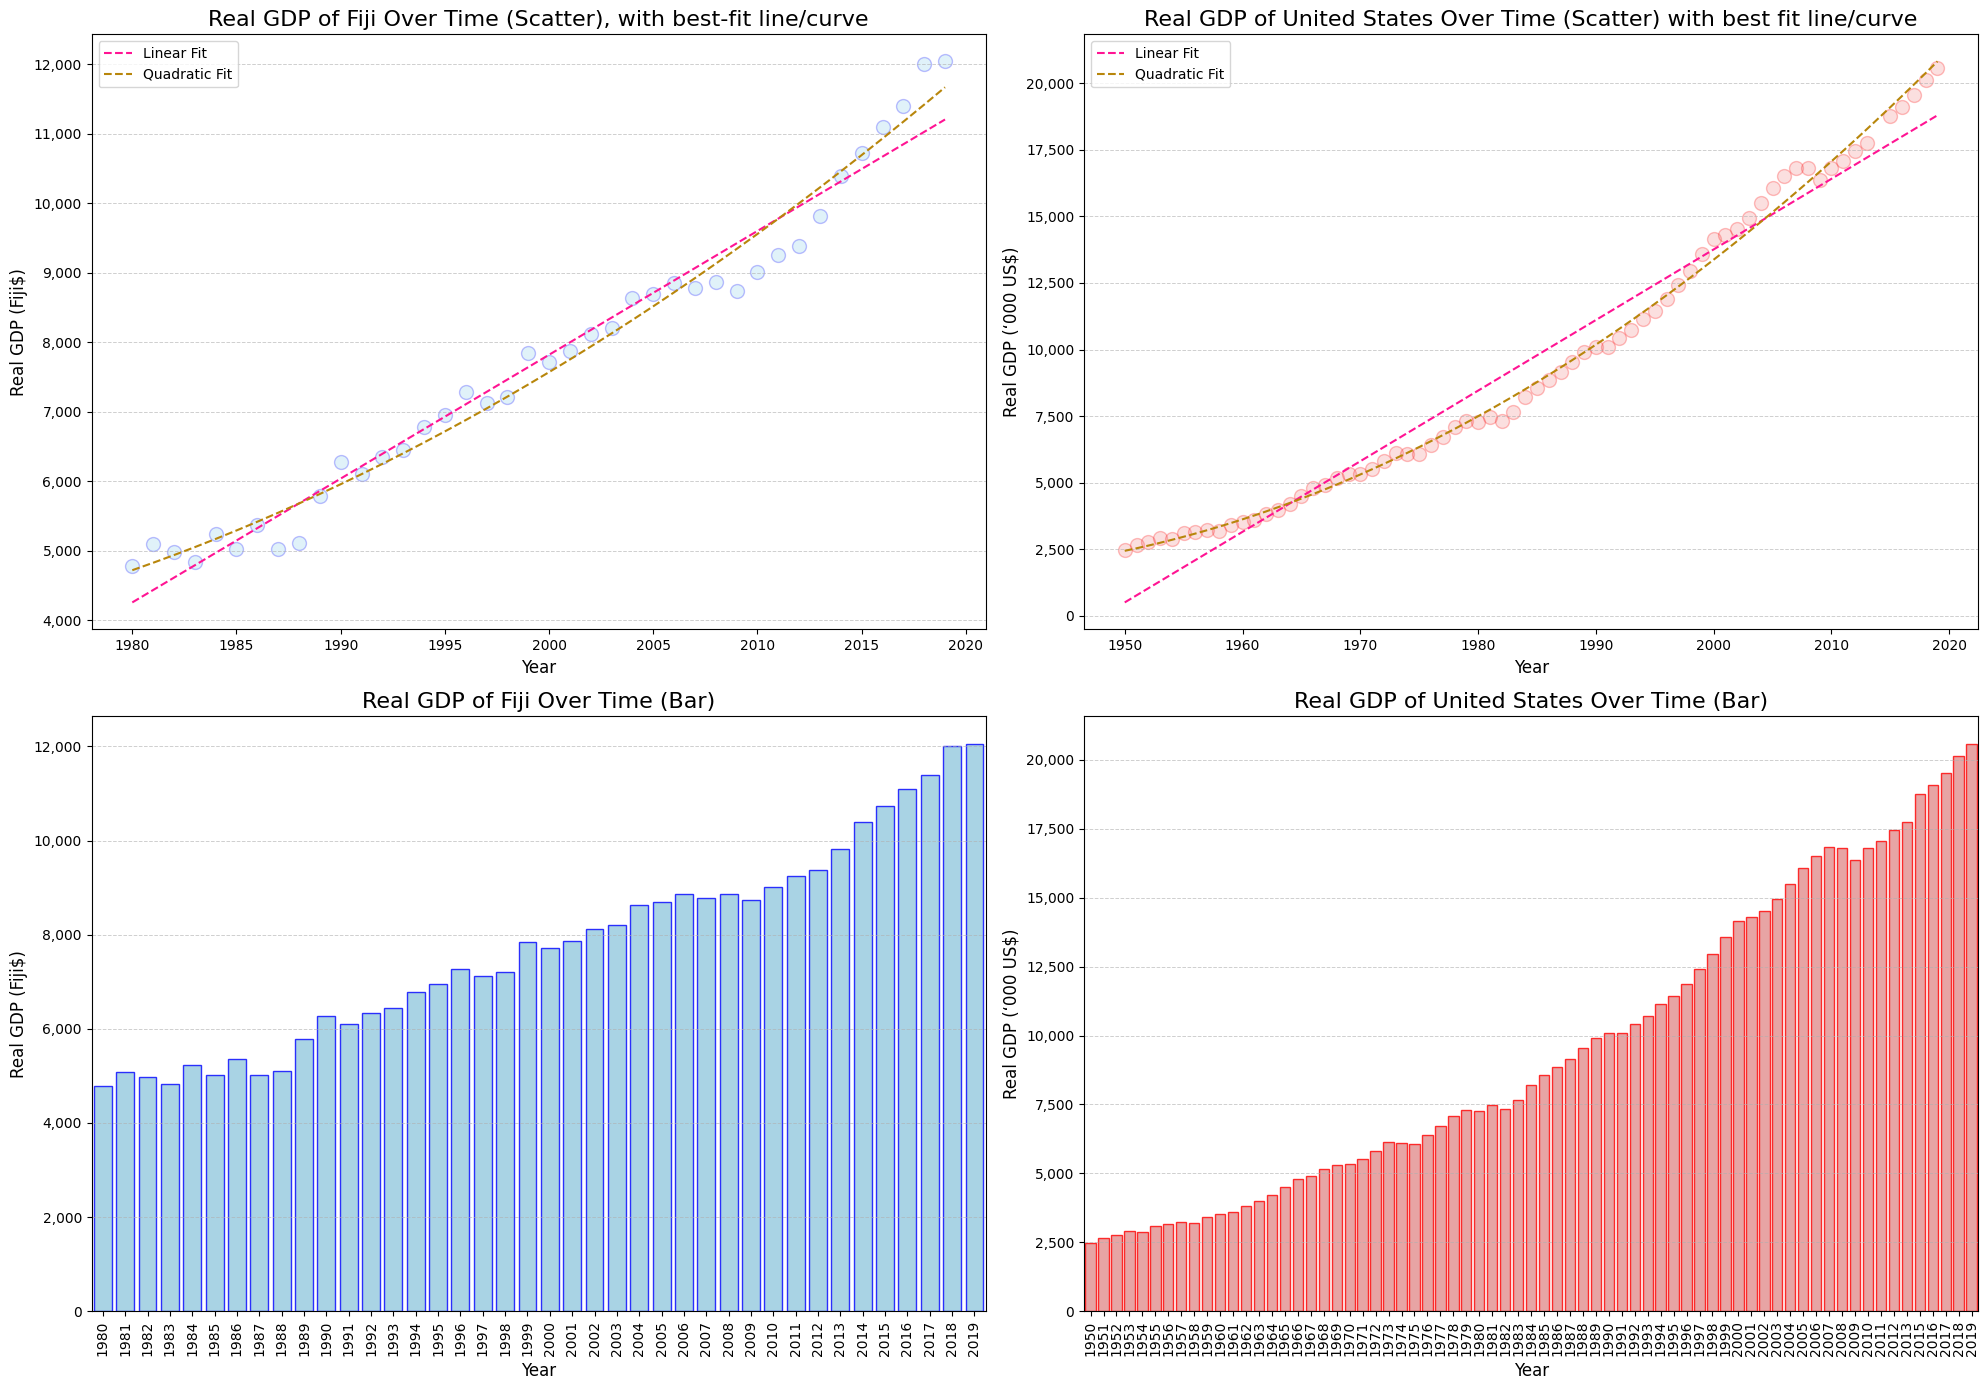

In [ ]:
# Filter data for Fiji and US
fiji_data = data_df_interpolated[data_df_interpolated['country'] == 'Fiji']
us_data = data_df_interpolated[data_df_interpolated['country'] == 'United States'].copy()

# Convert US Real GDP to '000US$'
us_data['Real GDP (thousands)'] = us_data['Real GDP'] / 1000

# Define colors
fiji_color = 'skyblue'
us_color = 'lightcoral'

# Define best-fit line colors
linear_fit_color = 'deeppink'
quadratic_fit_color = 'darkgoldenrod' # Using 'darkgoldenrod' for deeper yellow

# Create a figure with two rows and two columns for subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 14)) # 2 rows, 2 columns

# --- Plot for Fiji (top-left scatterplot) ---
sns.scatterplot(
    x='year',
    y='Real GDP',
    data=fiji_data,
    s=100,
    color=fiji_color,
    edgecolor='blue',
    linewidth=1,
    alpha=0.25, # Changed to 0.25 for 75% transparency
    ax=axes[0, 0] # First row, first column
)

# Calculate and plot Fiji linear best-fit
fiji_years = fiji_data['year'].values
fiji_gdp = fiji_data['Real GDP'].values
linear_coeffs_fiji = np.polyfit(fiji_years, fiji_gdp, 1)
linear_fit_fiji = np.poly1d(linear_coeffs_fiji)
axes[0, 0].plot(fiji_years, linear_fit_fiji(fiji_years), color=linear_fit_color, linestyle='--', label='Linear Fit')

# Calculate and plot Fiji quadratic best-fit
quadratic_coeffs_fiji = np.polyfit(fiji_years, fiji_gdp, 2)
quadratic_fit_fiji = np.poly1d(quadratic_coeffs_fiji)
axes[0, 0].plot(fiji_years, quadratic_fit_fiji(fiji_years), color=quadratic_fit_color, linestyle='--', label='Quadratic Fit')

axes[0, 0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[0, 0].grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
axes[0, 0].grid(False, which='both', axis='x')
axes[0, 0].set_title('Real GDP of Fiji Over Time (Scatter), with best-fit line/curve', fontsize=16)
axes[0, 0].set_xlabel('Year', fontsize=12)
axes[0, 0].set_ylabel('Real GDP (Fiji$)', fontsize=12)
axes[0, 0].legend()

# --- Plot for US (top-right scatterplot) ---
sns.scatterplot(
    x='year',
    y='Real GDP (thousands)', # Use the new scaled column
    data=us_data,
    s=100,
    color=us_color,
    edgecolor='red',
    linewidth=1,
    alpha=0.25, # Changed to 0.25 for 75% transparency
    ax=axes[0, 1] # First row, second column
)

# Calculate and plot US linear best-fit
us_years = us_data['year'].values
us_gdp = us_data['Real GDP (thousands)'].values
linear_coeffs_us = np.polyfit(us_years, us_gdp, 1)
linear_fit_us = np.poly1d(linear_coeffs_us)
axes[0, 1].plot(us_years, linear_fit_us(us_years), color=linear_fit_color, linestyle='--', label='Linear Fit')

# Calculate and plot US quadratic best-fit
quadratic_coeffs_us = np.polyfit(us_years, us_gdp, 2)
quadratic_fit_us = np.poly1d(quadratic_coeffs_us)
axes[0, 1].plot(us_years, quadratic_fit_us(us_years), color=quadratic_fit_color, linestyle='--', label='Quadratic Fit')

axes[0, 1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[0, 1].grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
axes[0, 1].grid(False, which='both', axis='x')
axes[0, 1].set_title('Real GDP of United States Over Time (Scatter) with best fit line/curve', fontsize=16)
axes[0, 1].set_xlabel('Year', fontsize=12)
axes[0, 1].set_ylabel('Real GDP (‘000 US$)', fontsize=12)
axes[0, 1].legend()

# --- Plot for Fiji (bottom-left bar chart) ---
sns.barplot(
    x='year',
    y='Real GDP',
    data=fiji_data,
    color=fiji_color,
    edgecolor='blue',
    linewidth=1,
    alpha=0.8,
    ax=axes[1, 0] # Second row, first column
)
axes[1, 0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[1, 0].grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
axes[1, 0].grid(False, which='both', axis='x')
axes[1, 0].set_title('Real GDP of Fiji Over Time (Bar)', fontsize=16)
axes[1, 0].set_xlabel('Year', fontsize=12)
axes[1, 0].set_ylabel('Real GDP (Fiji$)', fontsize=12)
axes[1, 0].set_xticks(axes[1, 0].get_xticks())
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)

# --- Plot for US (bottom-right bar chart) ---
sns.barplot(
    x='year',
    y='Real GDP (thousands)', # Use the new scaled column
    data=us_data,
    color=us_color,
    edgecolor='red',
    linewidth=1,
    alpha=0.8,
    ax=axes[1, 1] # Second row, second column
)
axes[1, 1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[1, 1].grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
axes[1, 1].grid(False, which='both', axis='x')
axes[1, 1].set_title('Real GDP of United States Over Time (Bar)', fontsize=16)
axes[1, 1].set_xlabel('Year', fontsize=12)
axes[1, 1].set_ylabel('Real GDP (‘000 US$)', fontsize=12)
axes[1, 1].set_xticks(axes[1, 1].get_xticks())
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## 3.2, Eurozone

### 3.2.1, Real GDP over Time

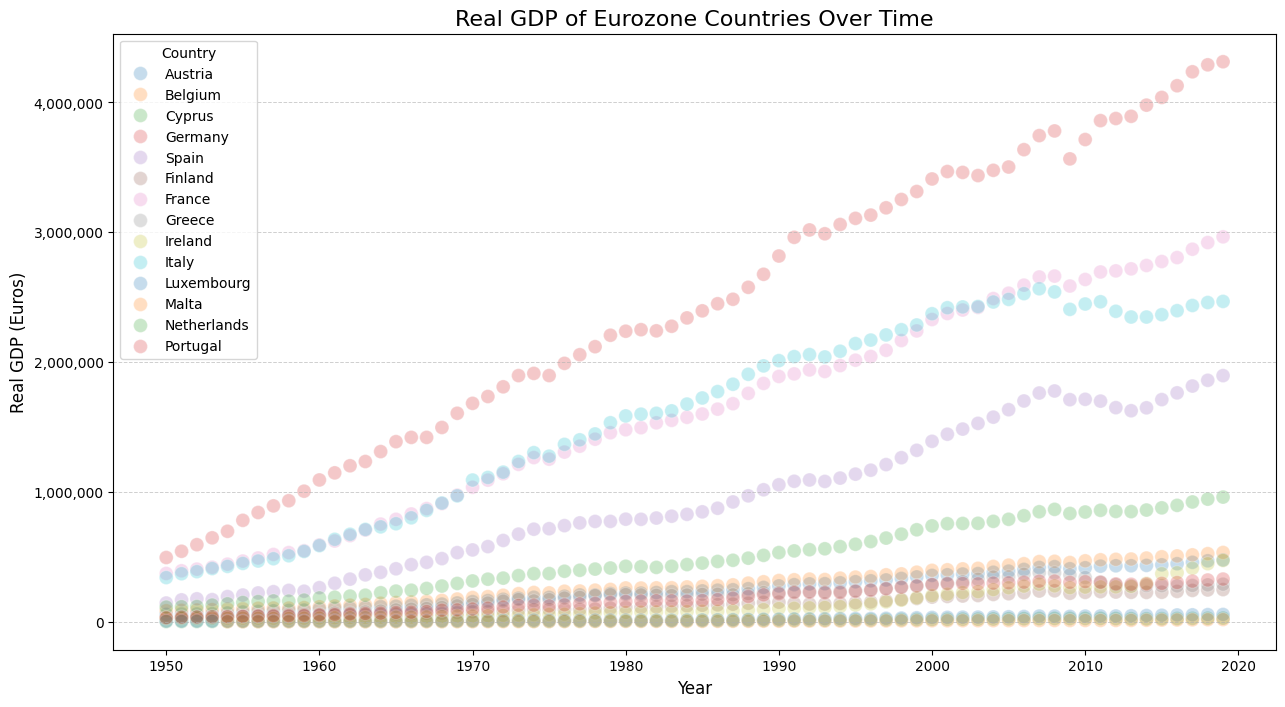

In [ ]:
# Identify Eurozone countries
eurozone_data = data_df_interpolated[data_df_interpolated['currency_unit'] == 'Euro']

# Get a list of unique Eurozone countries for the title and legend
eurozone_countries = eurozone_data['country'].unique()

# Create the scatterplot
plt.figure(figsize=(15, 8))
sns.scatterplot(
    x='year',
    y='Real GDP',
    hue='country', # Distinguish countries by color
    data=eurozone_data,
    s=100,
    alpha=0.25, # Changed to 0.25 for 75% transparency
    palette='tab10' # Use a distinct color palette
)

# Customize Y-axis for thousand comma separators
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Customize gridlines
plt.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
plt.grid(False, which='both', axis='x') # Remove vertical gridlines

# Add title and labels
plt.title(f'Real GDP of Eurozone Countries Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Real GDP (Euros)', fontsize=12)

# Add a legend to identify countries
plt.legend(title='Country')

# Show plot
plt.show()

But necessary to note that countries have their populations different. Then larger countries will be expected to have greater real GDPs innately. Somewhat biased?

Then plot **Per Capita GDP** instead:

### 3.2.2, GDP/Worker

In [ ]:
# Calculate 'GDP/Worker'
data_df_interpolated['GDP/Worker'] = data_df_interpolated['Real GDP'] / data_df_interpolated['Labour']

print("First 5 rows with new 'GDP/Worker' column:")
display(data_df_interpolated.head())

First 5 rows with new 'GDP/Worker' column:


,country,currency_unit,year,Real GDP,Capital,Labour,Human Capital,GDP/Worker
0,Angola,Kwanza,1970,54237.054688,295517.62500,3.666207,1.015686,14793.777342
1,Angola,Kwanza,1971,57491.277344,314195.09375,3.742484,1.018196,15361.796048
2,Angola,Kwanza,1972,57606.261719,332435.84375,3.853271,1.020712,14949.962783
3,Angola,Kwanza,1973,62272.367188,352647.90625,3.987807,1.023234,15615.692192
4,Angola,Kwanza,1974,64202.808594,373267.71875,4.130696,1.025762,15542.853791


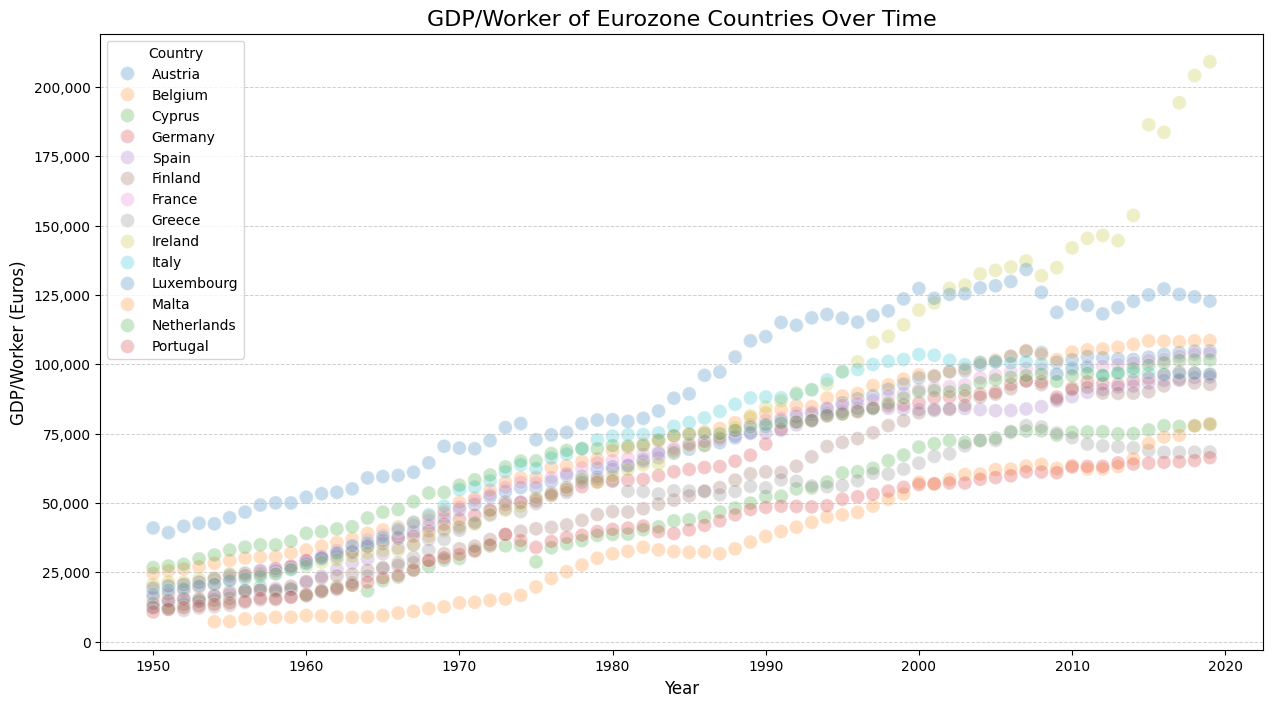

In [ ]:
# Identify Eurozone countries
eurozone_gdp_worker_data = data_df_interpolated[data_df_interpolated['currency_unit'] == 'Euro']

# Get a list of unique Eurozone countries for the title and legend
eurozone_countries_gdp_worker = eurozone_gdp_worker_data['country'].unique()

# Create the scatterplot for GDP/Worker
plt.figure(figsize=(15, 8))
sns.scatterplot(
    x='year',
    y='GDP/Worker',
    hue='country', # Distinguish countries by color
    data=eurozone_gdp_worker_data,
    s=100,
    alpha=0.25, # Changed to 0.25 for 75% transparency
    palette='tab10' # Use a distinct color palette
)

# Customize Y-axis for thousand comma separators
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Customize gridlines
plt.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
plt.grid(False, which='both', axis='x') # Remove vertical gridlines

# Add title and labels
plt.title(f'GDP/Worker of Eurozone Countries Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP/Worker (Euros)', fontsize=12)

# Add a legend to identify countries
plt.legend(title='Country')

# Show plot
plt.show()

# 4. Transforming Data & Running Regressions
creating an estimation of ln(Y_t) = αln(K_t) + βln(L_t)

## 4.1, Creating a Five-Year Average dataframe
For each country, pick the first year in data_df_interpolated as the starting year. From those years on, for each five-year period for each country, calculate the five-year averages of Real GDP, Capital, Labour, and Human Capital. Output the results in a new dataframe named 'averages', where 5-year averages are grouped by countries and respective 5-year periods.

### 4.1.1, Task
Create a DataFrame named `averages` containing the five-year averages of 'Real GDP', 'Capital', 'Labour', and 'Human Capital' for each country, where each five-year period starts from the first year recorded for that country in `data_df_interpolated`. Display the first few rows of the resulting `averages` DataFrame.

### 4.1.2, Prepare Data for Averaging

**Subtask**:
For each country, identify the first year present in `data_df_interpolated`. Then, create a 'period' column to group years into five-year intervals, starting from each country's first year.


In [ ]:
data_df_interpolated['first_year'] = data_df_interpolated.groupby('country')['year'].transform('min')
data_df_interpolated['period'] = (data_df_interpolated['year'] - data_df_interpolated['first_year']) // 5
data_df_interpolated['period_start_year'] = data_df_interpolated['first_year'] + (data_df_interpolated['period'] * 5)

print("DataFrame head with 'first_year', 'period', and 'period_start_year' columns:")
display(data_df_interpolated.head())

DataFrame head with 'first_year', 'period', and 'period_start_year' columns:


,country,currency_unit,year,Real GDP,Capital,Labour,Human Capital,GDP/Worker,first_year,period,period_start_year
0,Angola,Kwanza,1970,54237.054688,295517.62500,3.666207,1.015686,14793.777342,1970,0,1970
1,Angola,Kwanza,1971,57491.277344,314195.09375,3.742484,1.018196,15361.796048,1970,0,1970
2,Angola,Kwanza,1972,57606.261719,332435.84375,3.853271,1.020712,14949.962783,1970,0,1970
3,Angola,Kwanza,1973,62272.367188,352647.90625,3.987807,1.023234,15615.692192,1970,0,1970
4,Angola,Kwanza,1974,64202.808594,373267.71875,4.130696,1.025762,15542.853791,1970,0,1970


### 4.1.3, the DataFrame for 5-year averages

In [ ]:
averages = data_df_interpolated.groupby(['country', 'period', 'period_start_year'], as_index=False)[['Real GDP', 'Capital', 'Labour', 'Human Capital']].mean()

print("First few rows of the updated 'averages' DataFrame with 'period_start_year':")
display(averages.head())

First few rows of the updated 'averages' DataFrame with 'period_start_year':


,country,period,period_start_year,Real GDP,Capital,Labour,Human Capital
0,Albania,0,1970,9841.998047,50051.953125,0.817877,1.615809
1,Albania,1,1975,11983.823047,63970.472656,0.945654,1.773908
2,Albania,2,1980,14262.907812,81366.935938,1.103224,2.025428
3,Albania,3,1985,15591.980078,100351.967188,1.267616,2.357531
4,Albania,4,1990,11822.397266,108276.901563,1.150918,2.515308


**Reasoning**:
The previous steps successfully prepared the `data_df_interpolated` DataFrame with `first_year` and `period` columns. Now, I will group the DataFrame by 'country' and 'period' and calculate the mean of 'Real GDP', 'Capital', 'Labour', and 'Human Capital' to create the `averages` DataFrame as specified in the subtask.



## 4.2, Running Regression: ln(Y_t) = αln(K_t) + βln(L_t)

### 4.2.1, Adding natural logs of variables

In [ ]:
averages['log_Real_GDP'] = np.log(averages['Real GDP'])
averages['log_Capital'] = np.log(averages['Capital'])
averages['log_Labour'] = np.log(averages['Labour'])
averages['log_Human_Capital'] = np.log(averages['Human Capital'])

print("First few rows of 'averages' DataFrame with new log-transformed columns:")
display(averages.head())

First few rows of 'averages' DataFrame with new log-transformed columns:


,country,period,period_start_year,Real GDP,Capital,Labour,Human Capital,log_Real_GDP,log_Capital,log_Labour,log_Human_Capital
0,Albania,0,1970,9841.998047,50051.953125,0.817877,1.615809,9.194414,10.820817,-0.201043,0.479835
1,Albania,1,1975,11983.823047,63970.472656,0.945654,1.773908,9.391313,11.066177,-0.055879,0.573185
2,Albania,2,1980,14262.907812,81366.935938,1.103224,2.025428,9.565418,11.306724,0.098237,0.705781
3,Albania,3,1985,15591.980078,100351.967188,1.267616,2.357531,9.654512,11.516439,0.237138,0.857615
4,Albania,4,1990,11822.397266,108276.901563,1.150918,2.515308,9.377751,11.592447,0.140560,0.922395


### 4.2.2, Regression

In [ ]:
# Define the regression formula without an intercept (indicated by -1)
# Use the correct column name 'log_Real_GDP' which was created previously
formula = 'log_Real_GDP ~ log_Capital + log_Labour - 1'

# Fit the OLS model
model = smf.ols(formula, data=averages).fit()

# Display the regression results
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:           log_Real_GDP   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          4.031e+05
Date:                Tue, 24 Feb 2026   Prob (F-statistic):                        0.00
Time:                        12:04:17   Log-Likelihood:                         -1109.3
No. Observations:                1553   AIC:                                      2223.
Df Residuals:                    1551   BIC:                                      2233.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

note that the many of these parameters are different from the values in the instructions. But in most cases the differences seem to be acceptable (not a really large difference).

## 4.3, Actural vs Predicted Real GDP for Fiji

### 4.3.1, predicted real GDP values

In [ ]:
# Predict log_Real_GDP using the fitted model
averages['predicted_log_Real_GDP'] = model.predict(averages[['log_Capital', 'log_Labour']])

# Convert predicted_log_Real_GDP back to predicted_Real_GDP
averages['predicted_Real_GDP'] = np.exp(averages['predicted_log_Real_GDP'])

print("First few rows of 'averages' DataFrame with predicted GDP values:")
display(averages.head())

First few rows of 'averages' DataFrame with predicted GDP values:


,country,period,period_start_year,Real GDP,Capital,Labour,Human Capital,log_Real_GDP,log_Capital,log_Labour,log_Human_Capital,predicted_log_Real_GDP,predicted_Real_GDP
0,Albania,0,1970,9841.998047,50051.953125,0.817877,1.615809,9.194414,10.820817,-0.201043,0.479835,9.490022,13227.085034
1,Albania,1,1975,11983.823047,63970.472656,0.945654,1.773908,9.391313,11.066177,-0.055879,0.573185,9.727504,16772.643115
2,Albania,2,1980,14262.907812,81366.935938,1.103224,2.025428,9.565418,11.306724,0.098237,0.705781,9.962086,21206.986433
3,Albania,3,1985,15591.980078,100351.967188,1.267616,2.357531,9.654512,11.516439,0.237138,0.857615,10.167275,26037.040986
4,Albania,4,1990,11822.397266,108276.901563,1.150918,2.515308,9.377751,11.592447,0.140560,0.922395,10.219763,27440.160351


### 4.3.2, Comparing actural vs predicted GDP for Fiji (plots)

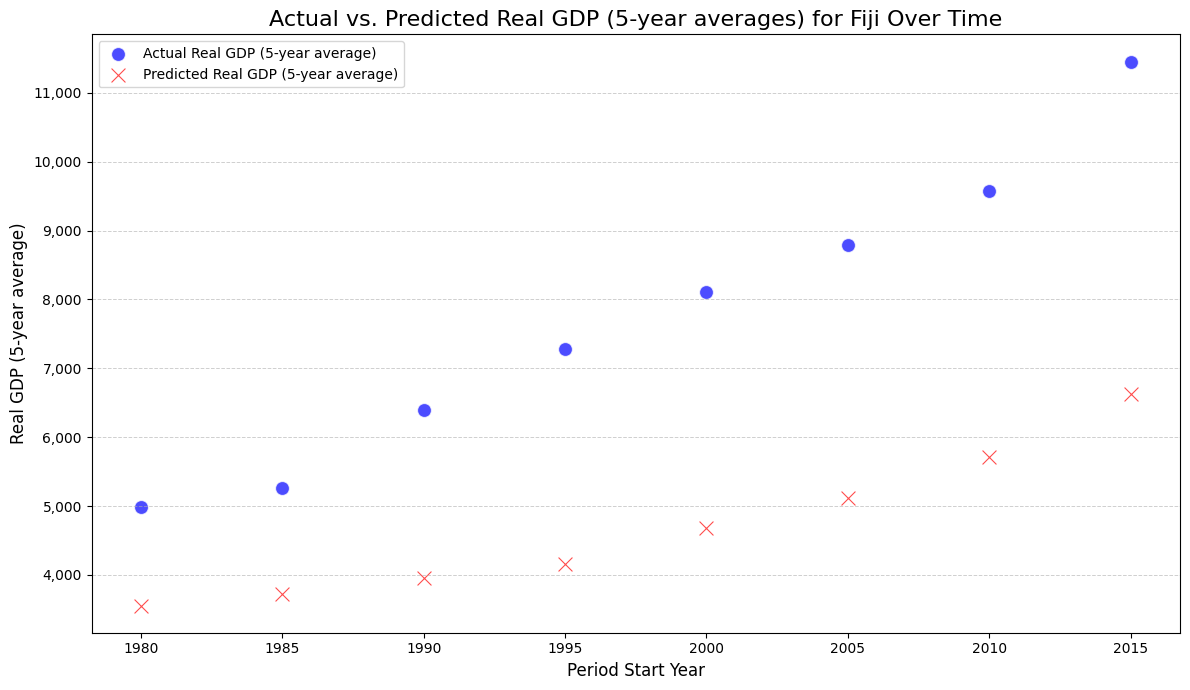

In [ ]:
# Filter data for Fiji from the averages DataFrame
fiji_averages = averages[averages['country'] == 'Fiji']

# Create the scatterplot
plt.figure(figsize=(12, 7))

sns.scatterplot(
    x='period_start_year',
    y='Real GDP',
    data=fiji_averages,
    label='Actual Real GDP (5-year average)',
    color='blue',
    s=100,
    alpha=0.7,
    marker='o'
)

sns.scatterplot(
    x='period_start_year',
    y='predicted_Real_GDP',
    data=fiji_averages,
    label='Predicted Real GDP (5-year average)',
    color='red',
    s=100,
    alpha=0.7,
    marker='x'
)

# Customize Y-axis for thousand comma separators
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Add title and labels
plt.title('Actual vs. Predicted Real GDP (5-year averages) for Fiji Over Time', fontsize=16)
plt.xlabel('Period Start Year', fontsize=12)
plt.ylabel('Real GDP (5-year average)', fontsize=12)

# Add grid and legend
plt.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
plt.grid(False, which='both', axis='x')
plt.legend()

plt.tight_layout()
plt.show()

### 4.3.3, Developing and Developed Countries

Here, I've chosen Zimbabwe and the United States. By common sense, the United States is a developed country and the largest economy of the world, whereas Zimbabwe compares smaller in size and is classified as a developing economy.

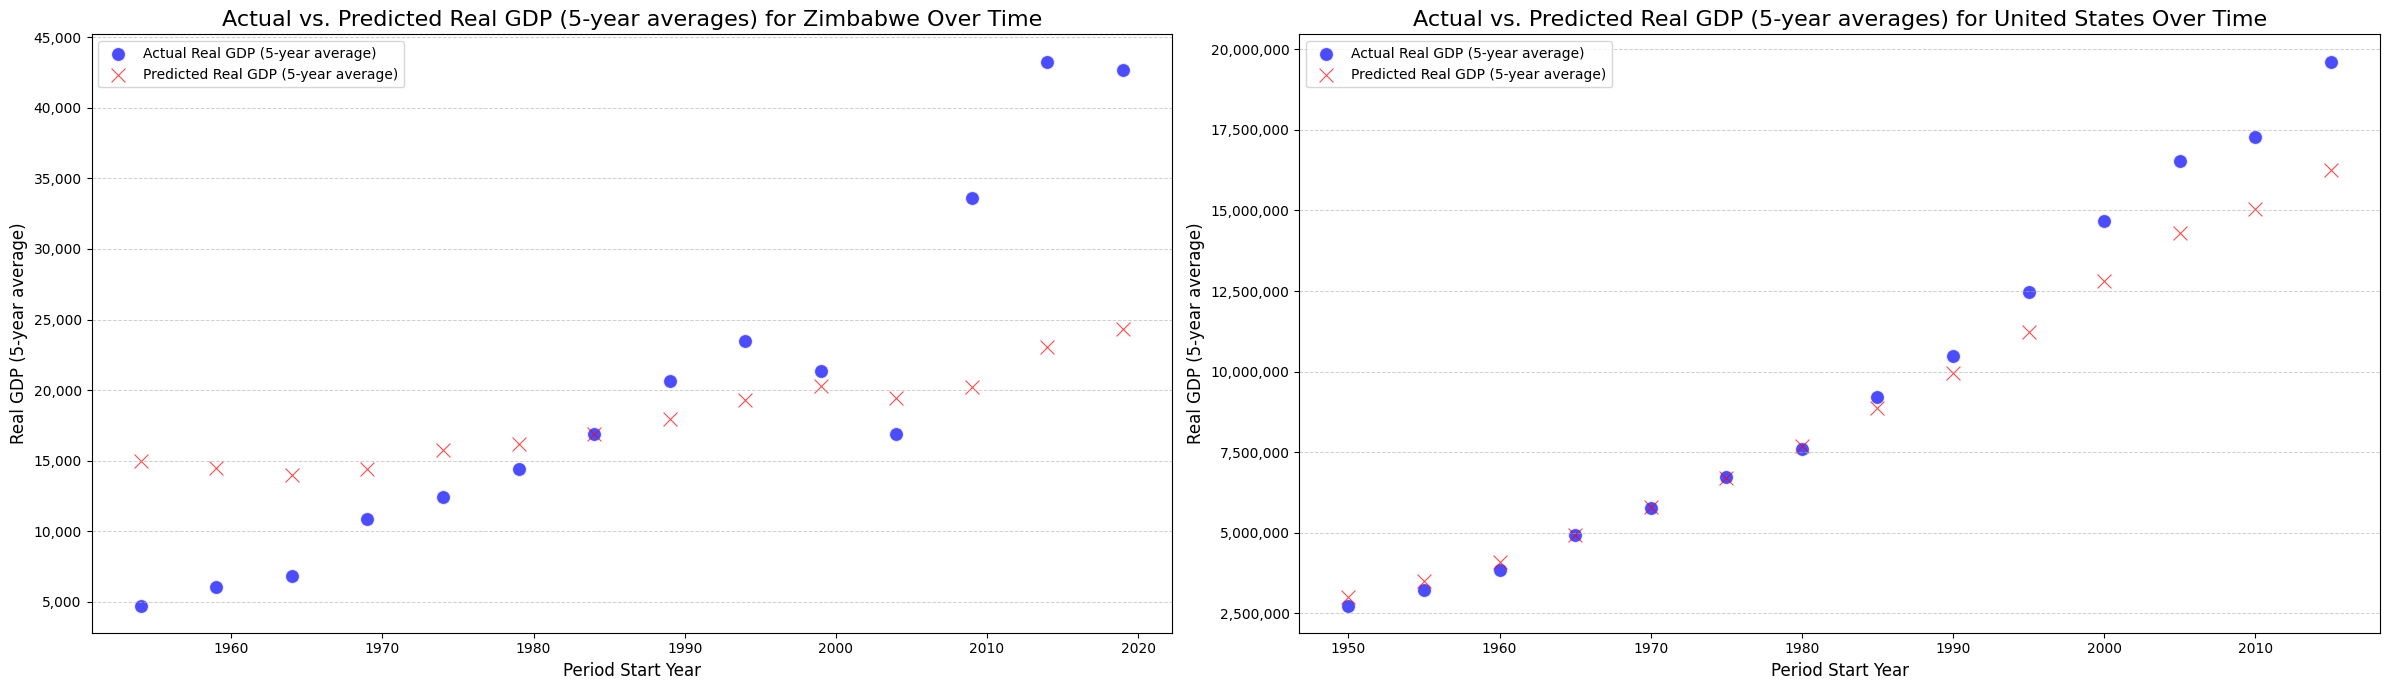

In [ ]:
# Filter data for Zimbabwe and United States from the averages DataFrame
zimbabwe_averages = averages[averages['country'] == 'Zimbabwe']
us_averages = averages[averages['country'] == 'United States']

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(24, 7)) # 1 row, 2 columns

# --- Plot for Zimbabwe (left subplot) ---
sns.scatterplot(
    x='period_start_year',
    y='Real GDP',
    data=zimbabwe_averages,
    label='Actual Real GDP (5-year average)',
    color='blue',
    s=100,
    alpha=0.7,
    marker='o',
    ax=axes[0]
)

sns.scatterplot(
    x='period_start_year',
    y='predicted_Real_GDP',
    data=zimbabwe_averages,
    label='Predicted Real GDP (5-year average)',
    color='red',
    s=100,
    alpha=0.7,
    marker='x',
    ax=axes[0]
)

# Customize Y-axis for thousand comma separators
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Add title and labels
axes[0].set_title('Actual vs. Predicted Real GDP (5-year averages) for Zimbabwe Over Time', fontsize=16)
axes[0].set_xlabel('Period Start Year', fontsize=12)
axes[0].set_ylabel('Real GDP (5-year average)', fontsize=12)

# Add grid and legend
axes[0].grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
axes[0].grid(False, which='both', axis='x')
axes[0].legend()

# --- Plot for United States (right subplot) ---
sns.scatterplot(
    x='period_start_year',
    y='Real GDP',
    data=us_averages,
    label='Actual Real GDP (5-year average)',
    color='blue',
    s=100,
    alpha=0.7,
    marker='o',
    ax=axes[1]
)

sns.scatterplot(
    x='period_start_year',
    y='predicted_Real_GDP',
    data=us_averages,
    label='Predicted Real GDP (5-year average)',
    color='red',
    s=100,
    alpha=0.7,
    marker='x',
    ax=axes[1]
)

# Customize Y-axis for thousand comma separators
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Add title and labels
axes[1].set_title('Actual vs. Predicted Real GDP (5-year averages) for United States Over Time', fontsize=16)
axes[1].set_xlabel('Period Start Year', fontsize=12)
axes[1].set_ylabel('Real GDP (5-year average)', fontsize=12)

# Add grid and legend
axes[1].grid(True, which='both', axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
axes[1].grid(False, which='both', axis='x')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.3.4, Comment on the accuracy of this simple model

**On average**, this regression is expected to provide **pretty decent estimation** of real GDP 5-year averages for countries, as shown by a pretty close-to-1 R^2 value (0.998). Meaning: the model claims that log capital and log labour are highly correlated to, or have quite crucial effects in "determining"/"explaning" log real GDP.

But note that there are still quite **observable differences between predictions and facts**. The model's predictions for 5-year average **real GDP for Fiji have always been lower than factual** real GDP averages. And the difference is so observably large that it's hard to claim it's insignificant. Maybe this is because Fiji, as a relatively less developed country, possess weaker ability to collect more data and thus to contribute to a more accurate model. Meanwhile, there might be some significant ommitted variables in Fiji influencing GDP stats other than the two variables in the model. More, the model is not so good at predicting economies with high degrees of fluctuation/**instability**: like it did for **Zimbabwe**. During the early periods, the model overestimated Zimbabwe's GDP stats, and later on when Zimbabwe displayed even higher degrees of instability and hyperinflation, the model could no longer offer precise predictions though it still captures the overall rising trend.

And for the **US**, as a developed, relatively stable economy with decent collections of data, the model seems to predict better. All predictions are quite close to facts. However, it's still notable that the model **isn't capturing the increasing growth rate** in GDP stats for the US, though the trend only seems observable during more recent periods -- maybe the linear model could not count the contribution of advancing technology to growth.

I've only done these few plots according to the instructions. But in fact plotting more of these "prediction vs fact" plots may help assess the model more in detail.